In [1]:
import numpy as np
import matplotlib.pyplot as plt

from adaptive_latents import Bubblewrap, BWRun, NumpyTimedDataSource, default_rwd_parameters
from adaptive_latents.transforms.utils import prosvd_data, clip
import adaptive_latents.plotting_functions as pf

In [2]:
stim = np.load("output_020424_ds1/photostims.npy") # these are stim times (frames?), I think

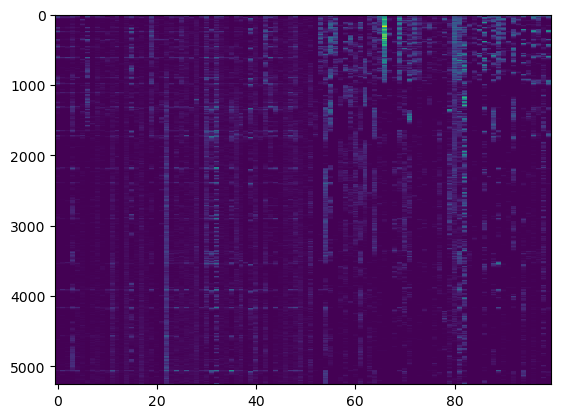

In [3]:
%matplotlib inline
C = np.loadtxt("output_020424_ds1/analysis_proc_C.txt") # C is calcium imaging data
# C adds columns over time, so we're going to slice out a portion that's nice to deal with

plt.imshow(C[:100, 150:].T, aspect='auto', interpolation='none') # this is a slice that we'll use

In [4]:
t = np.arange(C.shape[1]) # it looks like times are saved in units of frame number
in_data, t = C[:100, 150:].T, t[150:] # this does the slice
in_data = in_data

# this line applies proSVD all at once; it uses the streaming algorithm, but looks like it's offline
in_data = prosvd_data(in_data,7, 10, centering=True)

# check the docstring for clip
in_data, t = clip(in_data, t)


in_ds = NumpyTimedDataSource(in_data, t, time_offsets=(0,1))

bw = Bubblewrap(in_ds.output_shape, **default_rwd_parameters)
br = BWRun(bw, in_ds)
br.run()

  0%|          | 0/5245 [00:00<?, ?it/s]

100%|██████████| 5245/5245 [00:00<00:00, 10327.73it/s]


RuntimeError: Unable to initialize backend 'cuda': INTERNAL: no supported devices found for platform CUDA (you may need to uninstall the failing plugin package, or set JAX_PLATFORMS=cpu to skip this backend.)

array([   0., 1000., 2000., 3000., 4000., 5000., 6000., 2797.])

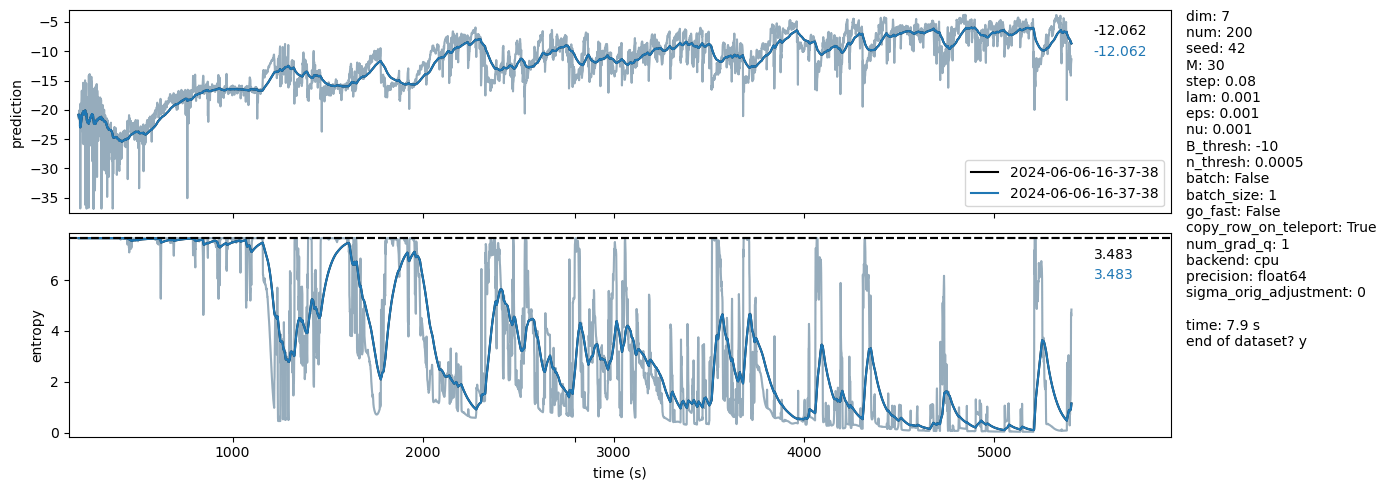

In [8]:
%matplotlib inline
pf.compare_metrics([br, br], offset=1, include_trendlines=True, show_target_times=True)

plt.gcf().axes[0].get_xticks()

# colors = t * 0;
# for ii, i in enumerate(stim[:,0]):
#     idx = np.nonzero(t > i)[0][0]
#     colors[idx:min(idx+10, len(colors))] = colors.max() + 1
#     for j in [0,1]:
#         fig.axes[j].axvline(i, color=f"C{ii//5}")
# fig.axes[0].set_xlim([2000,4000])

In [9]:
j = 0

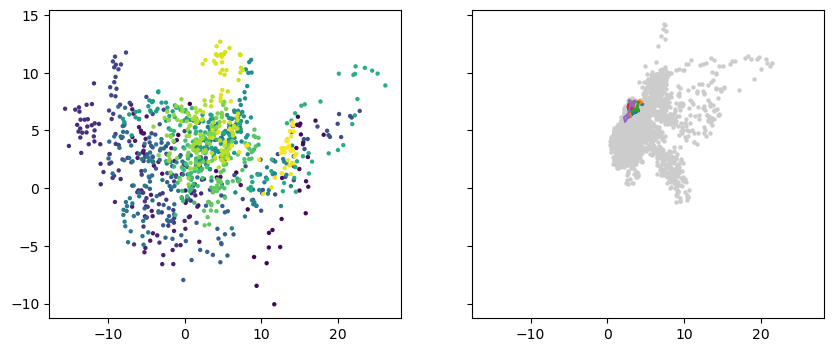

In [19]:
%matplotlib inline
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))
axis_0, axis_1 = 1,2

slice = t < stim[0,0]
axs[0].scatter(in_data[slice,axis_0], in_data[slice,axis_1], s=10, c=t[slice], lw=0)
axs[1].scatter(in_data[~slice,axis_0], in_data[~slice,axis_1], s=10, lw=0, color=np.array([1,1,1])*.8,)

r = np.arange(5*j,5*j+5)
assert np.std(stim[r,2]) == 0
for i in r:
    slice = (stim[i][0] <= t) & (t <= stim[i][0] + 34)
    axs[1].plot(in_data[slice,axis_0], in_data[slice,axis_1])
# j = j + 1

(2000.0, 3000.0)

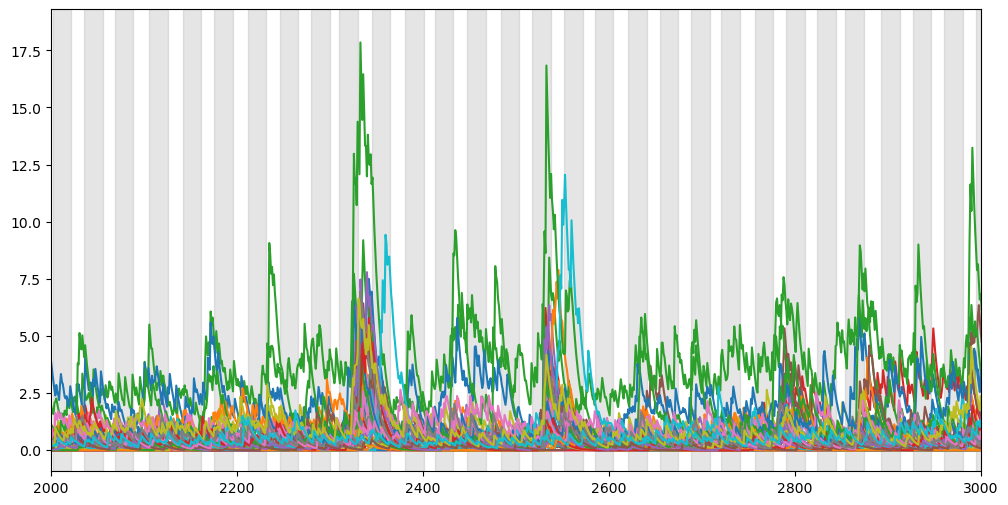

In [20]:
%matplotlib inline
duration = 20
init_dur = 0

fig, ax = plt.subplots(figsize=(12,6))

t1, t2 = 0, 4000

for neuron in range(50):
    plt.plot(np.arange(t1,t2), C[neuron,t1:t2], '-')
for i in np.arange(stim.shape[0]):
    if stim[i,0]+duration <= t2:
        ax.axvspan(stim[i,0]+init_dur, stim[i,0]+duration, alpha=0.2, color='gray')

plt.xlim([2000,3000])